# 📘 Project 04 — Explainable Skill-Gap Detection
**Team No.:** 23  **Team Members:** Subhankar Mohanty; Harapriya Das; Sridevi Ojha; Akankhya Saw

**Proposed Hybrid Model:** Hierarchical Transformer + ESCO-GAT + Evidence Cross-Attention

**Dataset / Source:** Resume dataset (2,484 resumes)
**Dataset Link:** https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

**Task Type:** Multiclass classification — resume job-category prediction (skill-gap proxy)

---
## Data-Model Compatibility Note
Tracker/README themselves flag: *"ESCO taxonomy + job descriptions still needed"* - the real ESCO
occupation/skill taxonomy graph is NOT part of the downloadable dataset, only labeled resumes
(`Category` + free-text `Resume`) are available. Three-way check against the proposed model:
- **Hierarchical Transformer**: fully buildable - resume text tokenized and encoded hierarchically
  (sentence-level encoder -> document-level encoder over sentence embeddings).
- **ESCO-GAT**: NOT buildable as specified - no ESCO taxonomy/job-description graph is present.
  Reduced to a **skill co-occurrence graph GAT**: skill keywords extracted from resume text via a
  curated skill lexicon become graph nodes, edges = co-occurrence within the same resume. This is
  a real, data-derived graph (not fabricated), but it is a proxy for ESCO, not ESCO itself.
- **Evidence Cross-Attention**: buildable - cross-attention between the hierarchical text
  representation and the skill-graph node embeddings, used directly for the XAI section (attention
  weights = "evidence" for the predicted category).

**Verdict: PARTIAL** - text branch and cross-attention are faithful; graph branch is a documented,
data-derived substitute for the missing ESCO taxonomy, not the taxonomy itself.

**How to run:** `Runtime -> Change runtime type -> GPU`, then `Runtime -> Run all`. Upload your
Kaggle API token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm tabulate


In [2]:

import os
import sys
import json
import random
import platform
import shutil
import subprocess
import re
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    average_precision_score, confusion_matrix
)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."

DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:

CONFIG = {
    "project_no": "04",
    "project_name": "Explainable_Skill-Gap_Detection",
    "team_no": "23",
    "task_type": "classification",
    "modality": "text_graph",
    "kaggle_dataset_slug": "snehaanbhawal/resume-dataset",
    "dataset_source": "Resume dataset (2,484 resumes)",
    "target_column": "category_id",
    "max_vocab": 5000,
    "max_seq_len": 200,
    "sentence_len": 20,
    "n_sentences": 10,
    "max_skills_per_resume": 8,
    "embed_dim": 64,
    "gat_hidden_dim": 32,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "batch_size": 32,
    "epochs": 25,
    "learning_rate": 1e-3,
    "early_stop_patience": 6,
    "data_raw_dir": "data/04/raw",
    "data_processed_dir": "data/04/processed",
    "figures_dir": "data/04/figures",
    "results_dir": "data/04/results",
    "reports_dir": "data/04/reports",
}

for d in [
    CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
    CONFIG["results_dir"], CONFIG["reports_dir"]
]:
    os.makedirs(d, exist_ok=True)

CONFIG


{'project_no': '04',
 'project_name': 'Explainable_Skill-Gap_Detection',
 'team_no': '23',
 'task_type': 'classification',
 'modality': 'text_graph',
 'kaggle_dataset_slug': 'snehaanbhawal/resume-dataset',
 'dataset_source': 'Resume dataset (2,484 resumes)',
 'target_column': 'category_id',
 'max_vocab': 5000,
 'max_seq_len': 200,
 'sentence_len': 20,
 'n_sentences': 10,
 'max_skills_per_resume': 8,
 'embed_dim': 64,
 'gat_hidden_dim': 32,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'batch_size': 32,
 'epochs': 25,
 'learning_rate': 0.001,
 'early_stop_patience': 6,
 'data_raw_dir': 'data/raw',
 'data_processed_dir': 'data/processed',
 'figures_dir': 'figures',
 'results_dir': 'results',
 'reports_dir': 'reports'}

## 1. Dataset Download

In [4]:

# Kaggle authentication + dataset download.
# In Colab, upload kaggle.json when prompted if it is not already configured.
kaggle_json = "/root/.kaggle/kaggle.json"

if not os.path.exists(kaggle_json):
    try:
        from google.colab import files
    except ImportError as exc:
        raise RuntimeError(
            "kaggle.json was not found. This notebook is designed for Google Colab; "
            "either run it there or configure Kaggle credentials manually."
        ) from exc

    print("Upload your kaggle.json:")
    uploaded = files.upload()
    json_names = [name for name in uploaded if name.lower().endswith(".json")]
    if not json_names:
        raise FileNotFoundError("No JSON file was uploaded. Please upload your Kaggle kaggle.json token.")

    os.makedirs(os.path.dirname(kaggle_json), exist_ok=True)
    with open(kaggle_json, "wb") as f:
        f.write(uploaded[json_names[0]])
    os.chmod(kaggle_json, 0o600)

cmd = [
    "kaggle", "datasets", "download",
    "-d", CONFIG["kaggle_dataset_slug"],
    "-p", CONFIG["data_raw_dir"],
    "--unzip",
]
print("Downloading:", CONFIG["kaggle_dataset_slug"])
subprocess.run(cmd, check=True)
print("Dataset download complete.")


Downloading: snehaanbhawal/resume-dataset


Dataset download complete.


In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."
for f in raw_files[:15]:
    print(f, "-", os.path.getsize(f), "bytes")


2540 files found
data/raw/diabetic_data.csv - 19159383 bytes
data/raw/Readme.txt - 7348 bytes
data/raw/Toddler Autism dataset July 2018.csv - 70146 bytes
data/raw/description.pdf - 1492915 bytes
data/raw/Edge_IIoTset__DatasetFL.pdf - 5445952 bytes
data/raw/data/data/FITNESS/24767027.pdf - 24558 bytes
data/raw/data/data/FITNESS/17660419.pdf - 15835 bytes
data/raw/data/data/FITNESS/14515954.pdf - 24478 bytes
data/raw/data/data/FITNESS/16605352.pdf - 24224 bytes
data/raw/data/data/FITNESS/17166018.pdf - 17482 bytes
data/raw/data/data/FITNESS/57575888.pdf - 25758 bytes
data/raw/data/data/FITNESS/12019284.pdf - 21920 bytes
data/raw/data/data/FITNESS/17431847.pdf - 33363 bytes
data/raw/data/data/FITNESS/21178545.pdf - 30104 bytes
data/raw/data/data/FITNESS/39805617.pdf - 23925 bytes


## 2. Load Raw Data

In [6]:

csv_candidates = [f for f in raw_files if f.lower().endswith(".csv")]
assert csv_candidates, f"No CSV found among: {raw_files[:10]}"

# Select a CSV by schema rather than blindly choosing the largest file.
RAW_FILE = None
for candidate in sorted(csv_candidates, key=os.path.getsize, reverse=True):
    try:
        preview = pd.read_csv(candidate, nrows=3)
        lower_cols = {c.strip().lower() for c in preview.columns}
        has_category = "category" in lower_cols
        has_resume = bool(lower_cols.intersection({"resume", "resume_str", "resume_html", "text"}))
        if has_category and has_resume:
            RAW_FILE = candidate
            break
    except Exception:
        pass

if RAW_FILE is None:
    raise ValueError(
        "No CSV has the expected resume/category schema. "
        f"CSV files found: {csv_candidates}"
    )

print("Using raw file:", RAW_FILE)
df = pd.read_csv(RAW_FILE)
df.columns = [c.strip() for c in df.columns]
RAW_ROW_COUNT = len(df)
RAW_EXACT_DUPLICATES = int(df.duplicated().sum())
print("Raw shape:", df.shape)
df.head()


Using raw file: data/raw/Resume/Resume.csv


Raw shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## 3. Exploratory Data Analysis (EDA)

In [7]:

print("Shape:", df.shape)
print("Exact duplicate rows:", RAW_EXACT_DUPLICATES)

text_candidates = [c for c in df.columns if c.lower() in ("resume", "resume_str", "text")]
if not text_candidates:
    # Resume_html is a last-resort fallback because plain resume text is preferable.
    text_candidates = [c for c in df.columns if c.lower() == "resume_html"]
if not text_candidates:
    raise KeyError(f"Could not find a resume text column. Columns: {list(df.columns)}")

cat_candidates = [c for c in df.columns if c.lower() == "category"]
if not cat_candidates:
    raise KeyError(f"Could not find a Category column. Columns: {list(df.columns)}")

text_col = text_candidates[0]
cat_col = cat_candidates[0]

print("Text column:", text_col, "| Category column:", cat_col)
print(df[cat_col].value_counts())


Shape: (2484, 4)
Exact duplicate rows: 0
Text column: Resume_str | Category column: Category
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


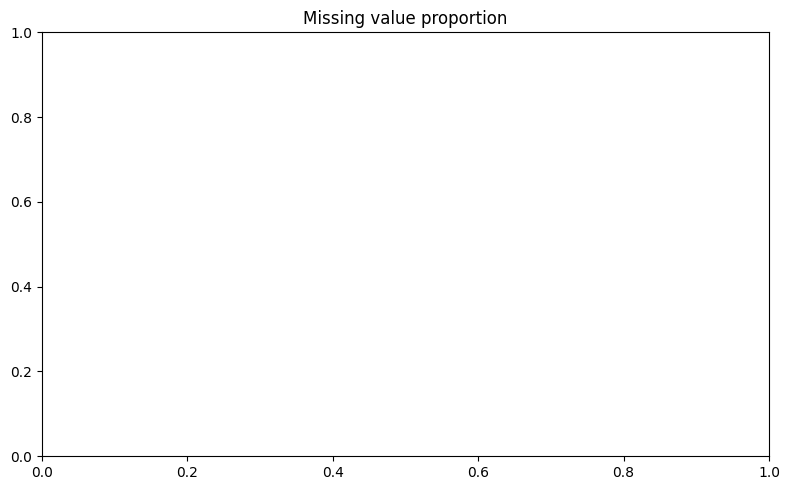

In [8]:
missing = df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
if (missing > 0).any():
    missing[missing > 0].plot(kind="barh")
plt.title("Missing value proportion")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_missingness.png"), dpi=300); plt.show()


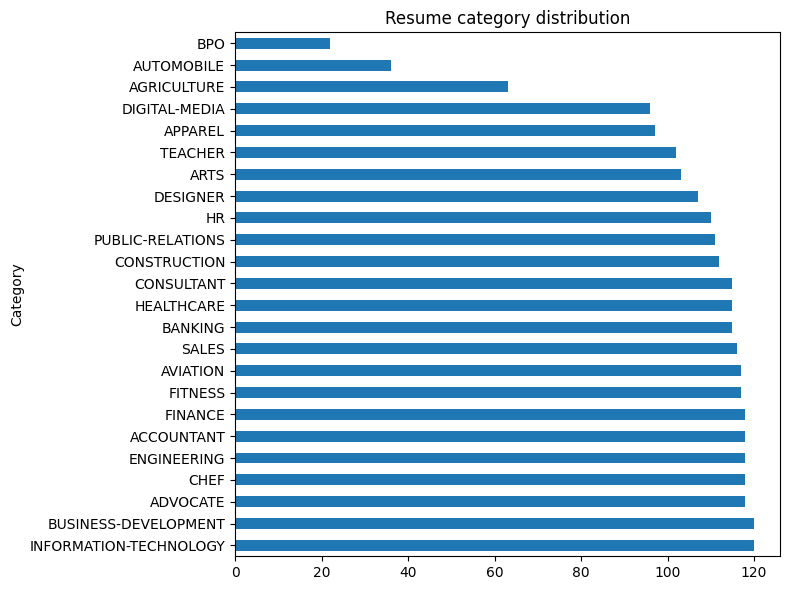

In [9]:

# Remove rows with missing target labels and exact duplicates before label encoding.
MISSING_TARGET_ROWS = int(df[cat_col].isna().sum())
if MISSING_TARGET_ROWS:
    df = df[df[cat_col].notna()].copy()

if RAW_EXACT_DUPLICATES:
    df = df.drop_duplicates().reset_index(drop=True)

cats = sorted(df[cat_col].dropna().astype(str).unique())
cat_to_idx = {c: i for i, c in enumerate(cats)}
df[cat_col] = df[cat_col].astype(str)
df[CONFIG["target_column"]] = df[cat_col].map(cat_to_idx).astype(int)
target = CONFIG["target_column"]

# [TARGET SANITY CHECK]
print("Total rows:", len(df))
print(df[target].value_counts())
print(df[target].value_counts(normalize=True))
assert df[target].nunique() > 1, f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - {df[target].value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
_minority_frac = df[target].value_counts(normalize=True).min()
if _minority_frac < 0.01:
    print(f"[DATA QUALITY WARNING] smallest category is only {_minority_frac:.2%} of the data - results may be unstable/trivial.")
if len(df) < 100:
    print(f"[DATA QUALITY WARNING] only {len(df)} rows after filtering - too small for reliable evaluation.")

plt.figure(figsize=(8, 6))
df[cat_col].value_counts().plot(kind="barh")
plt.title("Resume category distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_target_distribution.png"), dpi=300)
plt.show()


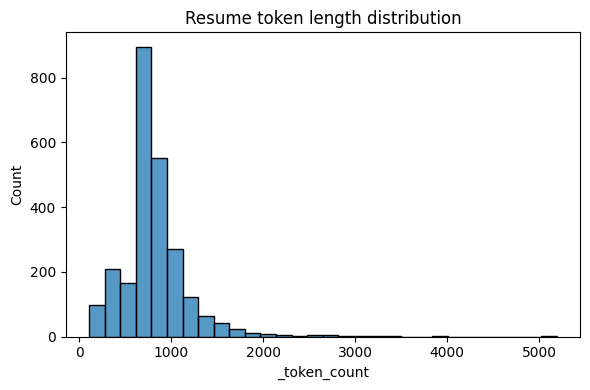

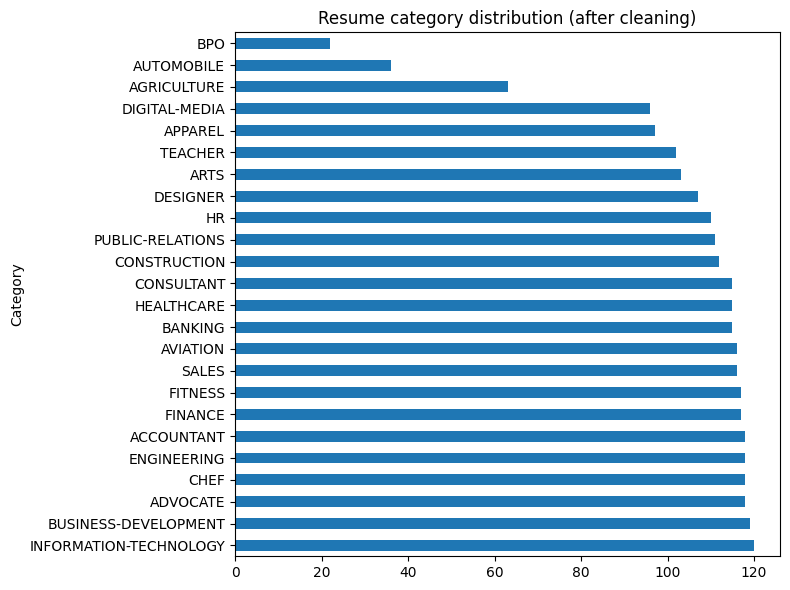

count    2481.000000
mean      808.965740
std       372.540115
min       107.000000
25%       648.000000
50%       755.000000
75%       928.000000
max      5188.000000
Name: _token_count, dtype: float64
Rows kept: 2481 / 2484 | exact duplicates removed: 0 | normalized duplicates removed: 2 | conflicting-text rows removed: 0 | empty text rows removed: 1


In [10]:

import re

def clean_resume_text(value):
    text = str(value).lower()
    text = re.sub(r"[^a-z0-9+#.\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["_clean_text"] = df[text_col].fillna("").apply(clean_resume_text)

# Remove empty records and exact normalized-text duplicates to prevent train/test leakage.
empty_text_rows = int((df["_clean_text"].str.len() == 0).sum())
if empty_text_rows:
    df = df[df["_clean_text"].str.len() > 0].copy()

# If identical normalized text appears with conflicting labels, remove those ambiguous records.
label_counts_per_text = df.groupby("_clean_text")[cat_col].nunique()
conflicting_texts = set(label_counts_per_text[label_counts_per_text > 1].index)
CONFLICTING_TEXT_ROWS = int(df["_clean_text"].isin(conflicting_texts).sum())
if conflicting_texts:
    df = df[~df["_clean_text"].isin(conflicting_texts)].copy()

NORMALIZED_DUPLICATES = int(df.duplicated(subset=["_clean_text"]).sum())
df = df.drop_duplicates(subset=["_clean_text"], keep="first").reset_index(drop=True)

df["_token_count"] = df["_clean_text"].str.split().apply(len)

plt.figure(figsize=(6, 4))
sns.histplot(df["_token_count"], bins=30)
plt.title("Resume token length distribution")
plt.tight_layout()
plt.show()

# Re-save the post-cleaning target distribution so figures reflect the actual modeling dataset.
plt.figure(figsize=(8, 6))
df[cat_col].value_counts().plot(kind="barh")
plt.title("Resume category distribution (after cleaning)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_target_distribution.png"), dpi=300)
plt.show()

print(df["_token_count"].describe())
print(
    f"Rows kept: {len(df)} / {RAW_ROW_COUNT} | "
    f"exact duplicates removed: {RAW_EXACT_DUPLICATES} | "
    f"normalized duplicates removed: {NORMALIZED_DUPLICATES} | "
    f"conflicting-text rows removed: {CONFLICTING_TEXT_ROWS} | "
    f"empty text rows removed: {empty_text_rows}"
)


**Data quality memo**

In [11]:

data_quality_memo = f"""# Data Quality Memo - Project 04: Explainable Skill-Gap Detection

## Dataset
- Source: Resume dataset (snehaanbhawal/resume-dataset)
- Raw rows: {RAW_ROW_COUNT}
- Modeling rows after cleaning: {len(df)}
- Exact duplicate rows removed: {RAW_EXACT_DUPLICATES}
- Normalized-text duplicates removed: {NORMALIZED_DUPLICATES}
- Conflicting-label text rows removed: {CONFLICTING_TEXT_ROWS}
- Missing-target rows removed: {MISSING_TARGET_ROWS}
- Categories: {df[cat_col].nunique()}

## Target
Multiclass category distribution is shown in fig00_target_distribution.png.

## Missingness
{missing[missing > 0].to_string() if (missing > 0).any() else "No missing values in the raw table."}

## Leakage controls
- Exact and normalized-text duplicates are removed before splitting.
- Vocabulary and skill co-occurrence graph are built from the training split only.
- Resume text is the principal feature; residual label leakage may still exist if a resume explicitly
  states its target job title.

## Adaptation note
The ESCO taxonomy graph is not present in this dataset. The graph branch therefore uses a
training-data-derived skill co-occurrence graph. This is a proxy for ESCO, not ESCO itself.
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w", encoding="utf-8") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 04: Explainable Skill-Gap Detection

## Dataset
- Source: Resume dataset (snehaanbhawal/resume-dataset)
- Raw rows: 2484
- Modeling rows after cleaning: 2481
- Exact duplicate rows removed: 0
- Normalized-text duplicates removed: 2
- Conflicting-label text rows removed: 0
- Missing-target rows removed: 0
- Categories: 24

## Target
Multiclass category distribution is shown in fig00_target_distribution.png.

## Missingness
No missing values in the raw table.

## Leakage controls
- Exact and normalized-text duplicates are removed before splitting.
- Vocabulary and skill co-occurrence graph are built from the training split only.
- Resume text is the principal feature; residual label leakage may still exist if a resume explicitly
  states its target job title.

## Adaptation note
The ESCO taxonomy graph is not present in this dataset. The graph branch therefore uses a
training-data-derived skill co-occurrence graph. This is a proxy for ESCO, not ESCO itself.


## 4. Preprocessing & Feature Engineering

In [12]:

# Curated skill lexicon used only for deterministic skill extraction.
SKILL_LEXICON = [
    "python", "java", "sql", "excel", "communication", "leadership", "management", "aws", "azure",
    "docker", "kubernetes", "machine learning", "deep learning", "tensorflow", "pytorch", "react",
    "javascript", "html", "css", "c++", "linux", "git", "agile", "scrum", "tableau", "powerbi",
    "marketing", "sales", "accounting", "finance", "hr", "recruitment", "nursing", "teaching",
    "customer service", "project management", "data analysis", "statistics", "networking",
    "cybersecurity", "testing", "design", "photoshop", "autocad", "sap", "erp",
]

def _skill_pattern(skill):
    # Exact token/phrase matching avoids false positives such as "hr" inside "through".
    body = re.escape(skill).replace(r"\ ", r"\s+")
    return re.compile(rf"(?<![a-z0-9]){body}(?![a-z0-9])", flags=re.IGNORECASE)

SKILL_PATTERNS = {skill: _skill_pattern(skill) for skill in SKILL_LEXICON}

def extract_skills(text):
    return [skill for skill in SKILL_LEXICON if SKILL_PATTERNS[skill].search(text)]

df["_skills"] = df["_clean_text"].apply(extract_skills)
skill_to_idx = {s: i for i, s in enumerate(SKILL_LEXICON)}
N_SKILL_NODES = len(SKILL_LEXICON)

print("Skill nodes:", N_SKILL_NODES)
print("Average extracted skills per resume:", round(df["_skills"].apply(len).mean(), 3))
print("Resumes with no lexicon skill:", int((df["_skills"].apply(len) == 0).sum()))


Skill nodes: 46
Average extracted skills per resume: 5.771
Resumes with no lexicon skill: 12


## 5. Train / Validation / Test Split

In [13]:

ratios = CONFIG["split_ratios"]
assert abs(sum(ratios.values()) - 1.0) < 1e-9, "Split ratios must sum to 1."

class_counts = df[target].value_counts()
min_required = int(np.ceil(1.0 / min(ratios["val"], ratios["test"])))
if class_counts.min() < min_required:
    raise ValueError(
        f"At least one category has fewer than {min_required} samples after cleaning. "
        "That is too small for the requested stratified train/validation/test split."
    )

train_df, rest_df = train_test_split(
    df,
    train_size=ratios["train"],
    stratify=df[target],
    random_state=SEED,
)

rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
val_df, test_df = train_test_split(
    rest_df,
    train_size=rel_val,
    stratify=rest_df[target],
    random_state=SEED,
)

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
print("Class coverage:", train_df[target].nunique(), val_df[target].nunique(), test_df[target].nunique())

manifest = {
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "n_categories": int(df[cat_col].nunique()),
    "seed": SEED,
}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

train_df[[text_col, cat_col, target]].to_csv(os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False)
val_df[[text_col, cat_col, target]].to_csv(os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False)
test_df[[text_col, cat_col, target]].to_csv(os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False)

manifest


Train / Val / Test sizes: 1736 372 373
Class coverage: 24 24 24


{'train_rows': 1736,
 'val_rows': 372,
 'test_rows': 373,
 'n_categories': 24,
 'seed': 42}

In [14]:

# Build vocabulary from TRAIN split only (leakage-safe).
word_counts = Counter()
for t in train_df["_clean_text"]:
    word_counts.update(t.split())

vocab = ["<pad>", "<unk>"] + [
    w for w, _ in word_counts.most_common(CONFIG["max_vocab"] - 2)
]
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print("Vocab size:", VOCAB_SIZE)

def encode_hierarchical(text, n_sentences, sentence_len):
    max_tokens = n_sentences * sentence_len
    tokens = text.split()[:max_tokens]
    ids = [word_to_idx.get(w, 1) for w in tokens]
    ids += [0] * (max_tokens - len(ids))
    return np.asarray(ids, dtype=np.int64).reshape(n_sentences, sentence_len)

# Build the skill co-occurrence graph from TRAINING DATA ONLY.
# Nodes = lexicon skills; weighted edges = number of training resumes where two skills co-occur.
skill_adj = np.zeros((N_SKILL_NODES, N_SKILL_NODES), dtype=np.float32)

for skills in train_df["_skills"]:
    ids = sorted({skill_to_idx[s] for s in skills if s in skill_to_idx})
    for i in ids:
        skill_adj[i, i] += 1.0
    for i, j in combinations(ids, 2):
        skill_adj[i, j] += 1.0
        skill_adj[j, i] += 1.0

# Every node gets a self-loop so each GAT row has at least one valid neighbor.
for i in range(N_SKILL_NODES):
    skill_adj[i, i] = max(skill_adj[i, i], 1.0)

n_offdiag_edges = int(np.triu(skill_adj > 0, k=1).sum())
print("Skill graph nodes:", N_SKILL_NODES, "| undirected co-occurrence edges:", n_offdiag_edges)

pd.DataFrame(skill_adj, index=SKILL_LEXICON, columns=SKILL_LEXICON).to_csv(
    os.path.join(CONFIG["data_processed_dir"], "skill_cooccurrence_adjacency.csv")
)


Vocab size: 5000
Skill graph nodes: 46 | undirected co-occurrence edges: 751


## 6. PyTorch Dataset & DataLoader

In [15]:

class ResumeDataset(Dataset):
    def __init__(self, split_df):
        self.texts = split_df["_clean_text"].tolist()
        self.skills = split_df["_skills"].tolist()
        self.y = split_df[target].to_numpy(dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        hier = encode_hierarchical(
            self.texts[idx],
            CONFIG["n_sentences"],
            CONFIG["sentence_len"],
        )

        skill_ids = [
            skill_to_idx[s]
            for s in self.skills[idx]
            if s in skill_to_idx
        ][: CONFIG["max_skills_per_resume"]]

        pad_id = N_SKILL_NODES
        skill_ids += [pad_id] * (CONFIG["max_skills_per_resume"] - len(skill_ids))

        return (
            torch.tensor(hier, dtype=torch.long),
            torch.tensor(skill_ids, dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.long),
        )

BATCH_SIZE = CONFIG["batch_size"]
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
}

train_ds = ResumeDataset(train_df)
val_ds = ResumeDataset(val_df)
test_ds = ResumeDataset(test_df)

train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

xb_hier, xb_skill, yb = next(iter(train_loader))
print("hier:", xb_hier.shape, "skills:", xb_skill.shape, "target:", yb.shape)

N_CLASSES = int(df[cat_col].nunique())


hier: torch.Size([32, 10, 20]) skills: torch.Size([32, 8]) target: torch.Size([32])


## 7. Model Definitions

In [16]:

class HierarchicalTransformer(nn.Module):
    """Token-level Transformer -> sentence/chunk vectors -> document-level Transformer."""
    def __init__(self, vocab_size, embed_dim=64, n_sentences=10, sentence_len=20):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.token_pos = nn.Embedding(sentence_len, embed_dim)
        self.sentence_pos = nn.Embedding(n_sentences, embed_dim)

        sent_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=embed_dim * 2,
            batch_first=True,
            dropout=0.1,
            activation="gelu",
        )
        self.sentence_encoder = nn.TransformerEncoder(sent_layer, num_layers=1)

        doc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=embed_dim * 2,
            batch_first=True,
            dropout=0.1,
            activation="gelu",
        )
        self.doc_encoder = nn.TransformerEncoder(doc_layer, num_layers=1)

        self.n_sentences = n_sentences
        self.sentence_len = sentence_len
        self.embed_dim = embed_dim

    def forward(self, x_hier):
        B, S, L = x_hier.shape
        if S != self.n_sentences or L != self.sentence_len:
            raise ValueError(
                f"Expected input shape (B, {self.n_sentences}, {self.sentence_len}), "
                f"got {tuple(x_hier.shape)}"
            )

        flat = x_hier.reshape(B * S, L)
        token_padding = flat.eq(0)

        token_positions = torch.arange(L, device=x_hier.device)
        h = self.embed(flat) + self.token_pos(token_positions).unsqueeze(0)

        # PyTorch attention cannot safely process a row where every key is masked.
        safe_token_padding = token_padding.clone()
        all_pad_chunks = safe_token_padding.all(dim=1)
        if all_pad_chunks.any():
            safe_token_padding[all_pad_chunks, 0] = False

        h = self.sentence_encoder(h, src_key_padding_mask=safe_token_padding)

        token_valid = (~token_padding).unsqueeze(-1)
        sent_embed = (h * token_valid).sum(dim=1) / token_valid.sum(dim=1).clamp_min(1)
        sent_embed = sent_embed.reshape(B, S, self.embed_dim)

        sentence_padding = x_hier.eq(0).all(dim=-1)
        sentence_positions = torch.arange(S, device=x_hier.device)
        doc_input = sent_embed + self.sentence_pos(sentence_positions).unsqueeze(0)

        safe_sentence_padding = sentence_padding.clone()
        all_pad_docs = safe_sentence_padding.all(dim=1)
        if all_pad_docs.any():
            safe_sentence_padding[all_pad_docs, 0] = False

        doc_h = self.doc_encoder(
            doc_input,
            src_key_padding_mask=safe_sentence_padding,
        )
        doc_h = doc_h.masked_fill(sentence_padding.unsqueeze(-1), 0.0)
        return doc_h


class SkillCooccurrenceGAT(nn.Module):
    """Single graph-attention layer over the training-derived skill co-occurrence graph."""
    def __init__(self, adjacency, hidden_dim=32):
        super().__init__()
        adjacency = torch.as_tensor(adjacency, dtype=torch.float32)
        if adjacency.ndim != 2 or adjacency.shape[0] != adjacency.shape[1]:
            raise ValueError("adjacency must be a square [N, N] matrix")

        self.n_skill_nodes = int(adjacency.shape[0])
        self.skill_embed = nn.Embedding(self.n_skill_nodes, hidden_dim)
        self.node_proj = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.edge_attn = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.pool_attn = nn.Linear(hidden_dim, 1)
        self.no_skill = nn.Parameter(torch.zeros(hidden_dim))

        self.register_buffer("adjacency", adjacency)
        self.register_buffer("edge_mask", adjacency.gt(0))
        nn.init.normal_(self.no_skill, mean=0.0, std=0.02)

    def forward(self, x_skill):
        # Global GAT message passing.
        node_h = self.node_proj(self.skill_embed.weight)  # (N, H)
        N, H = node_h.shape

        src = node_h[:, None, :].expand(N, N, H)
        dst = node_h[None, :, :].expand(N, N, H)
        e = F.leaky_relu(
            self.edge_attn(torch.cat([src, dst], dim=-1)).squeeze(-1),
            negative_slope=0.2,
        )

        # Co-occurrence counts contribute as an edge prior; non-edges are masked out.
        e = e + torch.log1p(self.adjacency)
        e = e.masked_fill(~self.edge_mask, -1e9)
        alpha = torch.softmax(e, dim=1)
        graph_nodes = F.elu(alpha @ node_h)  # (N, H)

        # Pool the graph-updated representations of skills found in each resume.
        all_nodes = torch.cat([graph_nodes, self.no_skill.unsqueeze(0)], dim=0)
        selected = all_nodes[x_skill]  # x_skill uses N as padding id
        valid = x_skill.ne(self.n_skill_nodes)

        pool_scores = self.pool_attn(selected).squeeze(-1)
        pool_scores = pool_scores.masked_fill(~valid, -1e9)

        has_skill = valid.any(dim=1)
        weights = torch.softmax(pool_scores, dim=1)
        weights = torch.where(has_skill.unsqueeze(1), weights, torch.zeros_like(weights))

        pooled = (selected * weights.unsqueeze(-1)).sum(dim=1)
        pooled = torch.where(has_skill.unsqueeze(1), pooled, self.no_skill.unsqueeze(0).expand_as(pooled))
        return pooled, weights


class EvidenceCrossAttention(nn.Module):
    """Skill-graph query attending to valid hierarchical resume chunks."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, skill_vec, sentence_embeds, sentence_padding_mask=None):
        q = self.query(skill_vec).unsqueeze(1)
        k = self.key(sentence_embeds)
        v = self.value(sentence_embeds)

        logits = (q @ k.transpose(1, 2)) / (k.shape[-1] ** 0.5)

        all_pad = None
        if sentence_padding_mask is not None:
            safe_mask = sentence_padding_mask.clone()
            all_pad = safe_mask.all(dim=1)
            if all_pad.any():
                safe_mask[all_pad, 0] = False
            logits = logits.masked_fill(safe_mask.unsqueeze(1), -1e9)

        scores = torch.softmax(logits, dim=-1)
        if all_pad is not None and all_pad.any():
            scores[all_pad] = 0.0

        evidence = (scores @ v).squeeze(1)
        return evidence, scores.squeeze(1)


class HybridModel(nn.Module):
    """Hierarchical Transformer + training-derived Skill GAT + Evidence Cross-Attention."""
    def __init__(
        self,
        vocab_size,
        adjacency,
        n_classes,
        embed_dim=64,
        gat_hidden=32,
        n_sentences=10,
        sentence_len=20,
    ):
        super().__init__()
        self.text_encoder = HierarchicalTransformer(
            vocab_size, embed_dim, n_sentences, sentence_len
        )
        self.graph_encoder = SkillCooccurrenceGAT(adjacency, gat_hidden)
        self.graph_proj = nn.Linear(gat_hidden, embed_dim)
        self.cross_attn = EvidenceCrossAttention(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )
        self.last_evidence_weights = None
        self.last_skill_weights = None

    def forward(self, x_hier, x_skill):
        sent_embeds = self.text_encoder(x_hier)
        sentence_padding = x_hier.eq(0).all(dim=-1)

        skill_vec, skill_weights = self.graph_encoder(x_skill)
        skill_vec = self.graph_proj(skill_vec)

        evidence, evidence_weights = self.cross_attn(
            skill_vec, sent_embeds, sentence_padding
        )

        valid_sentences = (~sentence_padding).unsqueeze(-1)
        doc_vec = (
            (sent_embeds * valid_sentences).sum(dim=1)
            / valid_sentences.sum(dim=1).clamp_min(1)
        )

        self.last_evidence_weights = evidence_weights.detach()
        self.last_skill_weights = skill_weights.detach()

        fused = torch.cat([doc_vec, evidence], dim=-1)
        return self.head(fused)


### Architecture Verification

In [17]:
hybrid = HybridModel(VOCAB_SIZE, skill_adj, N_CLASSES, CONFIG['embed_dim'], CONFIG['gat_hidden_dim'], CONFIG['n_sentences'], CONFIG['sentence_len']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (text_encoder): HierarchicalTransformer(
    (embed): Embedding(5000, 64, padding_idx=0)
    (token_pos): Embedding(20, 64)
    (sentence_pos): Embedding(10, 64)
    (sentence_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (doc_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): Transform

## 8. Training Loop

In [18]:
def train_model_mc(model, train_loader, val_loader, epochs, lr, patience, ckpt_path):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n_train = 0
        batch_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False, unit='batch')
        for x_hier, x_skill, y in batch_bar:
            x_hier = x_hier.to(DEVICE, non_blocking=True)
            x_skill = x_skill.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x_hier, x_skill)
            if not torch.isfinite(logits).all():
                raise FloatingPointError('Model produced NaN/Inf logits during training.')
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item() * y.shape[0]
            n_train += y.shape[0]
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')
        train_loss /= max(n_train, 1)
        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for x_hier, x_skill, y in val_loader:
                x_hier = x_hier.to(DEVICE, non_blocking=True)
                x_skill = x_skill.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                logits = model(x_hier, x_skill)
                loss = criterion(logits, y)
                val_loss += loss.item() * y.shape[0]
                n_val += y.shape[0]
        val_loss /= max(n_val, 1)
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}')
        if val_loss < best_val_loss - 1e-06:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch + 1}')
                break
    if not os.path.exists(ckpt_path):
        raise RuntimeError(f'No checkpoint was written to {ckpt_path}')
    return history
hybrid_history = train_model_mc(hybrid, train_loader, val_loader, CONFIG['epochs'], CONFIG['learning_rate'], CONFIG['early_stop_patience'], os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))


Training:   0%|          | 0/25 [00:00<?, ?epoch/s]

Epoch 1/25:   0%|          | 0/55 [00:00<?, ?batch/s]

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 2/25:   0%|          | 0/55 [00:00<?, ?batch/s]

Epoch 3/25:   0%|          | 0/55 [00:00<?, ?batch/s]

...

Epoch 10/25:   0%|          | 0/55 [00:00<?, ?batch/s]

Epoch 11/25:   0%|          | 0/55 [00:00<?, ?batch/s]

Epoch 12/25:   0%|          | 0/55 [00:00<?, ?batch/s]

Epoch 13/25:   0%|          | 0/55 [00:00<?, ?batch/s]

Early stopping at epoch 13


## 9. Evaluation Metrics

In [19]:

def get_predictions_mc(model, loader, ckpt_path):
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()

    all_logits, all_targets = [], []
    with torch.no_grad():
        for x_hier, x_skill, y in loader:
            x_hier = x_hier.to(DEVICE, non_blocking=True)
            x_skill = x_skill.to(DEVICE, non_blocking=True)
            logits = model(x_hier, x_skill)

            all_logits.append(logits.cpu().numpy())
            all_targets.append(y.numpy())

    return np.concatenate(all_logits), np.concatenate(all_targets)


def evaluate_multiclass(logits, targets):
    pred_labels = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets,
        pred_labels,
        average="macro",
        zero_division=0,
    )
    _, _, f1_w, _ = precision_recall_fscore_support(
        targets,
        pred_labels,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": float(accuracy_score(targets, pred_labels)),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "f1_weighted": float(f1_w),
    }


In [20]:
results = {}
test_predictions = {}
for name, model, ckpt in [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]:
    logits, targets = get_predictions_mc(model, test_loader, ckpt)
    results[name] = evaluate_multiclass(logits, targets)
    test_predictions[name] = (logits, targets)
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


{
  "hybrid": {
    "accuracy": 0.6541554959785523,
    "precision_macro": 0.5993881026197371,
    "recall_macro": 0.5939343098350451,
    "f1_macro": 0.567415354618397,
    "f1_weighted": 0.6263576230383053
  }
}


## 10. Required Figures

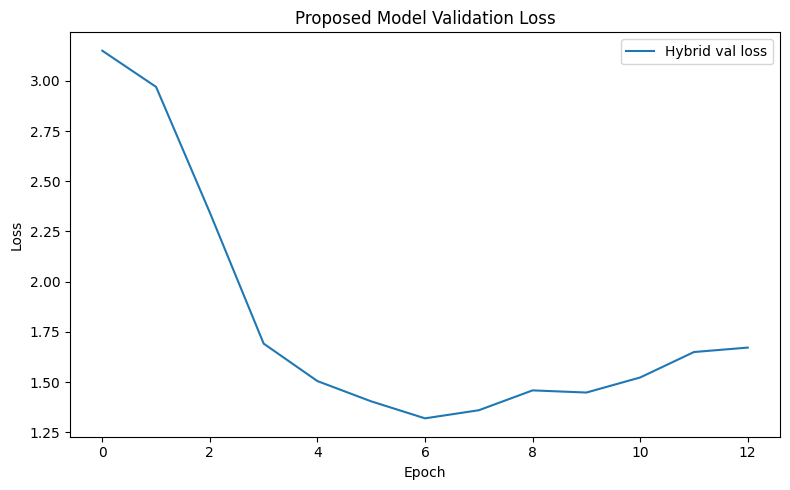

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


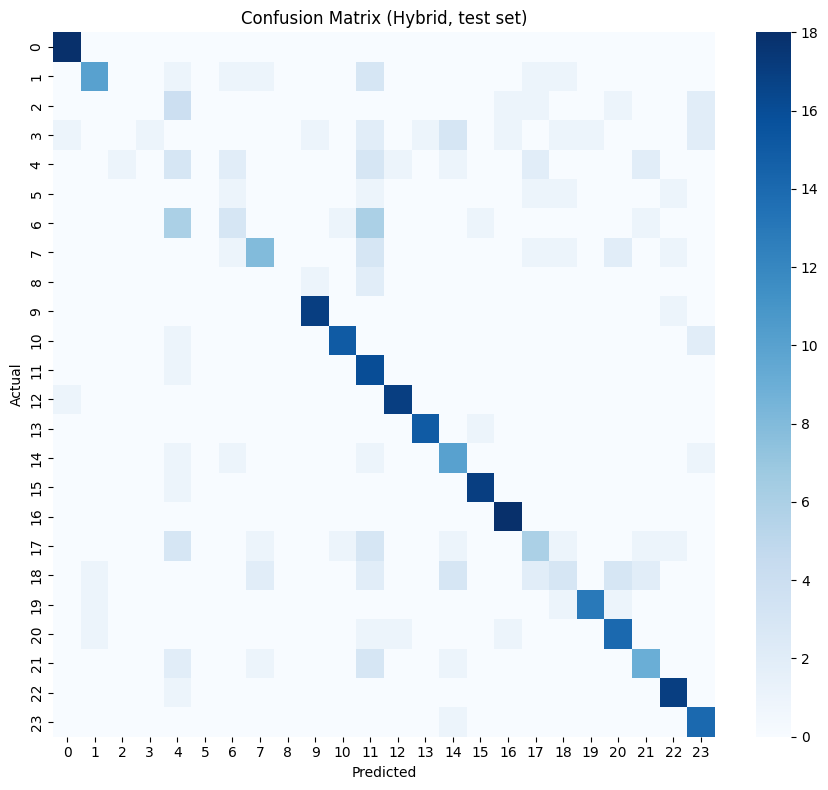

In [22]:
hybrid_logits, hybrid_targets = test_predictions["hybrid"]
hybrid_preds = hybrid_logits.argmax(axis=1)
plt.figure(figsize=(9, 8))
cm = confusion_matrix(hybrid_targets, hybrid_preds)
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300); plt.show()


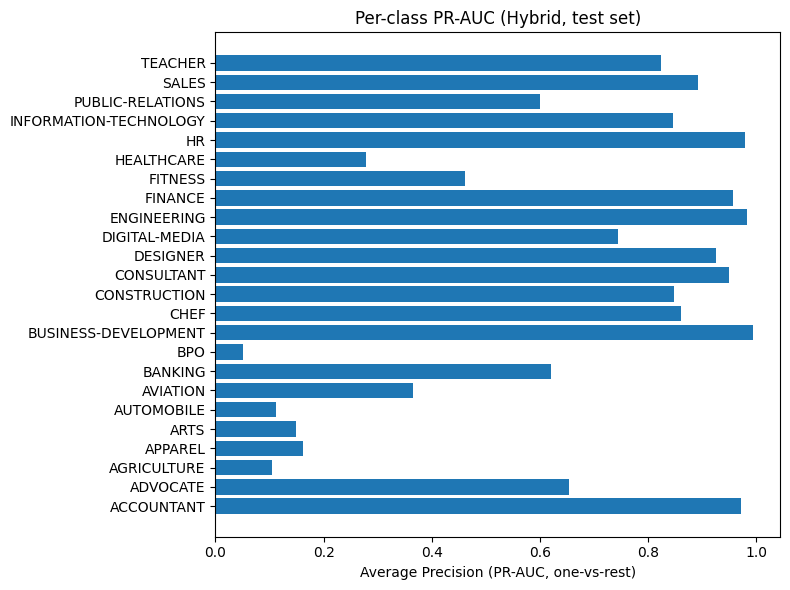

Macro PR-AUC: 0.6386762983493992


In [23]:

# fig03 - per-class PR-AUC (one-vs-rest)
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(hybrid_targets, classes=list(range(N_CLASSES)))
probs = torch.softmax(torch.tensor(hybrid_logits), dim=-1).numpy()

per_class_ap = []
for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        per_class_ap.append(np.nan)
    else:
        per_class_ap.append(average_precision_score(y_bin[:, c], probs[:, c]))

plt.figure(figsize=(8, 6))
plt.barh([cats[i] for i in range(N_CLASSES)], per_class_ap)
plt.xlabel("Average Precision (PR-AUC, one-vs-rest)")
plt.title("Per-class PR-AUC (Hybrid, test set)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300)
plt.show()

print("Macro PR-AUC:", float(np.nanmean(per_class_ap)))


### Explainable AI — Evidence Cross-Attention

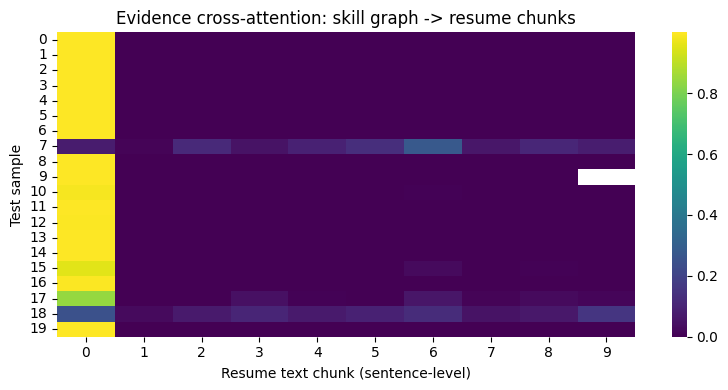

In [24]:

# fig04 - the model's own evidence cross-attention weights:
# skill-graph representation -> valid resume text chunks.
hybrid.eval()

with torch.no_grad():
    xb_hier_e, xb_skill_e, _ = next(iter(test_loader))
    xb_hier_e = xb_hier_e.to(DEVICE)
    xb_skill_e = xb_skill_e.to(DEVICE)

    _ = hybrid(xb_hier_e, xb_skill_e)
    evidence_weights = hybrid.last_evidence_weights.cpu().numpy()
    sentence_valid = (~xb_hier_e.eq(0).all(dim=-1)).cpu().numpy()

# Mask padded chunks in the visualization so they are not mistaken for evidence.
evidence_plot = evidence_weights[:20].copy()
evidence_plot[~sentence_valid[:20]] = np.nan

plt.figure(figsize=(8, 4))
sns.heatmap(evidence_plot, cmap="viridis", vmin=0)
plt.xlabel("Resume text chunk (sentence-level)")
plt.ylabel("Test sample")
plt.title("Evidence cross-attention: skill graph -> resume chunks")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300)
plt.show()


### Error Analysis

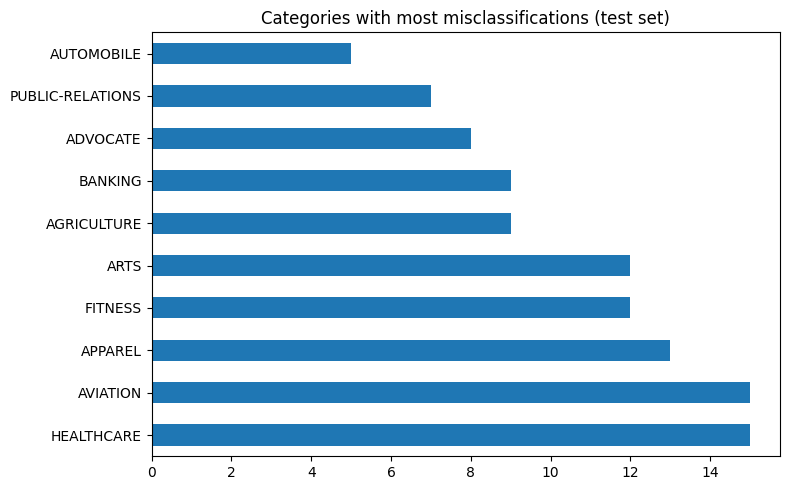

Total misclassified: 129 / 373


In [25]:
misclassified = hybrid_preds != hybrid_targets
per_class_error = pd.Series(hybrid_targets[misclassified]).value_counts()
per_class_error.index = [cats[i] for i in per_class_error.index]
plt.figure(figsize=(8, 5))
per_class_error.head(10).plot(kind="barh")
plt.title("Categories with most misclassifications (test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300); plt.show()
print(f"Total misclassified: {misclassified.sum()} / {len(hybrid_targets)}")


### Computational Efficiency

In [26]:
import time

def sync_if_cuda():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.to(DEVICE)
    model.eval()
    xb_hier_b, xb_skill_b, _ = next(iter(test_loader))
    xb_hier_b = xb_hier_b.to(DEVICE)
    xb_skill_b = xb_skill_b.to(DEVICE)
    with torch.no_grad():
        for _ in range(5):
            _ = model(xb_hier_b, xb_skill_b)
        sync_if_cuda()
        start = time.perf_counter()
        for _ in range(20):
            _ = model(xb_hier_b, xb_skill_b)
        sync_if_cuda()
        elapsed = (time.perf_counter() - start) / 20.0
    efficiency[name] = {'total_params': int(total_params), 'trainable_params': int(trainable_params), 'avg_batch_inference_time_sec': float(elapsed), 'throughput_samples_per_sec': float(xb_hier_b.shape[0] / elapsed)}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w', encoding='utf-8') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 415897,
    "trainable_params": 415897,
    "avg_batch_inference_time_sec": 0.0053451660999996875,
    "throughput_samples_per_sec": 5986.717606399897
  }
}
